# Data Preparation

In [6]:
!pip install adjustText

In [7]:
# Mengimpor library Pandas untuk manipulasi data berbentuk tabel (dataframe)
import pandas as pd

# Mengimpor library Numpy untuk operasi matematika dan pengolahan array/matriks
import numpy as np

# Mengimpor library Seaborn untuk membuat visualisasi data statistik yang menarik
import seaborn as sns
from adjustText import adjust_text


# Mengimpor modul Pyplot dari Matplotlib untuk membuat grafik dan kustomisasi plot
import matplotlib.pyplot as plt


Mengimpor library yang diperlukan dalam analisis data, yaitu pandas untuk pengolahan data, numpy untuk perhitungan numerik, serta seaborn dan matplotlib untuk visualisasi data.

In [8]:
# Membaca file CSV bernama "House Price Prediction Dataset.csv" ke dalam variabel df (DataFrame)
df = pd.read_csv("Bike Price Prediction.csv")

# Menampilkan 5 baris data teratas untuk memeriksa isi kolom dan format datanya
df.head()


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


Kode tersebut digunakan untuk membaca file dataset berformat CSV ke dalam DataFrame menggunakan pandas, kemudian menampilkan 5 baris pertama dari data untuk melihat struktur dan isi dataset.


In [9]:
# Melihat dimensi dataset (jumlah baris dan jumlah kolom) dalam bentuk tuple (baris, kolom)
df.shape


(1061, 7)

Kode tersebut digunakan untuk melihat ukuran dataset, yaitu jumlah baris dan kolom yang terdapat dalam DataFrame.

In [10]:
# Menampilkan ringkasan informasi dataset, termasuk tipe data tiap kolom, jumlah baris, dan jumlah nilai yang terisi (non-null)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


Kode tersebut digunakan untuk menampilkan informasi umum dataset, seperti jumlah data, nama kolom, tipe data, serta jumlah nilai yang tidak kosong pada setiap kolom.

In [11]:
# Menghitung jumlah nilai kosong (NaN/null) pada setiap kolom di dalam dataset
missing_val = df.isnull().sum()

# Menampilkan hasil perhitungan jumlah nilai kosong untuk seluruh variabel/kolom
print(missing_val)


name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


Kode tersebut digunakan untuk menghitung dan menampilkan jumlah nilai kosong (missing value) pada setiap kolom dalam dataset.

In [12]:
# # Mencari kemunculan nilai spesifik yang sering digunakan sebagai pengganti data kosong (seperti "Unknown" atau "?") pada seluruh dataframe, lalu menjumlahkannya per kolom
df.isin(["Unknown", "NA", "N/A", "?", "None"]).sum()


,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,0


Kode tersebut digunakan untuk mendeteksi dan menghitung jumlah nilai tertentu (seperti "Unknown", "NA", "?", dll) yang sering digunakan sebagai pengganti data kosong pada setiap kolom dalam dataset.


In [13]:
# Mendeteksi baris yang memiliki nilai identik di seluruh kolom, kemudian menjumlahkan total baris yang duplikat tersebut
df.duplicated().sum()


np.int64(6)

In [14]:
# Menampilkan ringkasan statistik deskriptif untuk kolom-kolom numerik, seperti rata-rata, standar deviasi, nilai minimum, kuartil, dan nilai maksimum
df.describe()


,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [15]:
# Menampilkan ringkasan statistik untuk kolom bertipe objek (teks/kategorik), seperti jumlah nilai unik, nilai yang paling sering muncul, dan frekuensinya
df.describe(include='object')


,name,seller_type,owner
count,1061,1061,1061
unique,279,2,4
top,Bajaj Pulsar 150,Individual,1st owner
freq,41,1055,924


In [16]:
# Menghitung Kuartil 1 (persentil ke-25) dari kolom 'Price'
Q1 = df['selling_price'].quantile(0.25)

# Menghitung Kuartil 3 (persentil ke-75) dari kolom 'Price'
Q3 = df['selling_price'].quantile(0.75)

# Menghitung selisih antara Q3 dan Q1 untuk mendapatkan rentang interkuartil (IQR)
IQR = Q3 - Q1

# Menentukan batas bawah untuk mendeteksi outlier (di bawah Q1 - 1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR

# Menentukan batas atas untuk mendeteksi outlier (di atas Q3 + 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# Mencari baris data yang nilai 'Price'-nya berada di luar batas bawah atau batas atas (pencilan)
outliers = df[(df['selling_price'] < lower_bound) | (df['selling_price'] > upper_bound)]

# Menampilkan total jumlah baris yang terdeteksi sebagai outlier
print(len(outliers))


87


In [17]:
# Menghitung jumlah kemunculan (frekuensi) untuk setiap kategori unik di dalam kolom 'Condition'
# Hasilnya akan menunjukkan berapa banyak motor yang masuk kategori 'Good', 'New', 'Old', dsb.
df['seller_type'].value_counts()


,count
seller_type,
Individual,1055
Dealer,6


In [18]:
# Menghitung frekuensi atau jumlah kemunculan setiap kategori lokasi di dalam kolom 'Location'
# Ini membantu mengetahui area mana yang paling dominan dalam dataset motor tersebut
df['owner'].value_counts()


,count
owner,
1st owner,924
2nd owner,123
3rd owner,11
4th owner,3


In [19]:
# Menghitung jumlah kemunculan setiap jenis atau status garasi di dalam kolom 'Garage'
# Digunakan untuk mengetahui distribusi kategori garasi (misalnya: 'Yes'/'No' atau jumlah slot parkir)
df['name'].value_counts()


,count
name,
Bajaj Pulsar 150,41
Royal Enfield Classic 350,27
Honda Activa [2000-2015],23
Honda CB Hornet 160R,22
Bajaj Pulsar 180,20
...,...
Hero Splender Plus,1
Hero Glamour,1
Hero Ignitor Disc,1


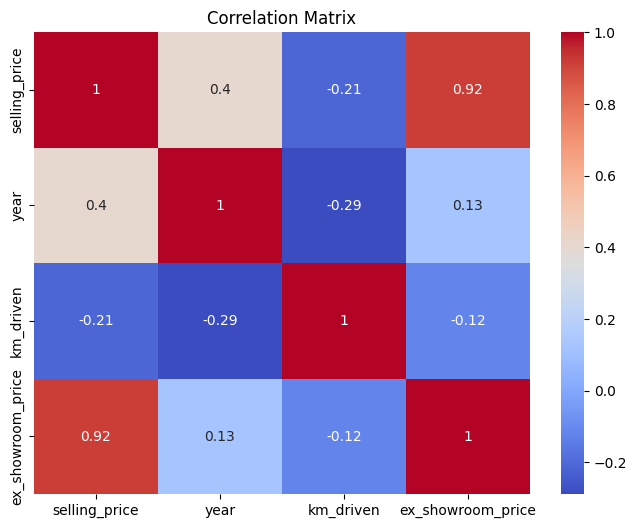

In [20]:
# Menghitung koefisien korelasi antar kolom numerik saja (menghindari error pada kolom teks)
corr_matrix = df.corr(numeric_only=True)

# Mengatur ukuran jendela grafik (lebar 8 inci, tinggi 6 inci) agar visualisasi tidak terlalu rapat
plt.figure(figsize=(8,6))

# Membuat heatmap dengan nilai korelasi yang ditampilkan di dalam kotak (annot=True)
# serta menggunakan skema warna coolwarm (biru untuk negatif, merah untuk positif)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Memberikan judul pada grafik agar mudah dipahami informasinya
plt.title('Correlation Matrix')

# Menampilkan grafik yang telah dibuat ke layar
plt.show()


In [21]:
# # Menghapus kolom 'Id' dari dataframe karena tidak memiliki nilai prediktif (hanya nomor urut/identitas)
# # axis=1 menentukan bahwa yang dihapus adalah kolom (bukan baris)
# df = df.drop(['Id'], axis=1)


In [22]:
# df.head()

# EDA (Eksplorasi Data Analysis)

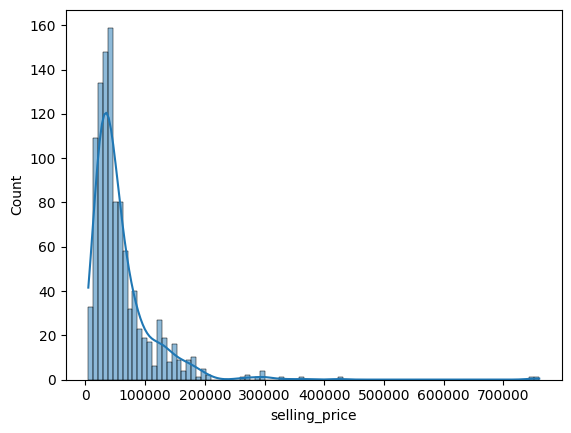

In [23]:
# Membuat grafik histogram untuk melihat persebaran data pada kolom target 'Price'
# kde=True menambahkan garis Estimasi Kepadatan Kernel untuk memperhalus bentuk distribusi
sns.histplot(df['selling_price'], kde=True)

# Menampilkan grafik ke layar
plt.show()


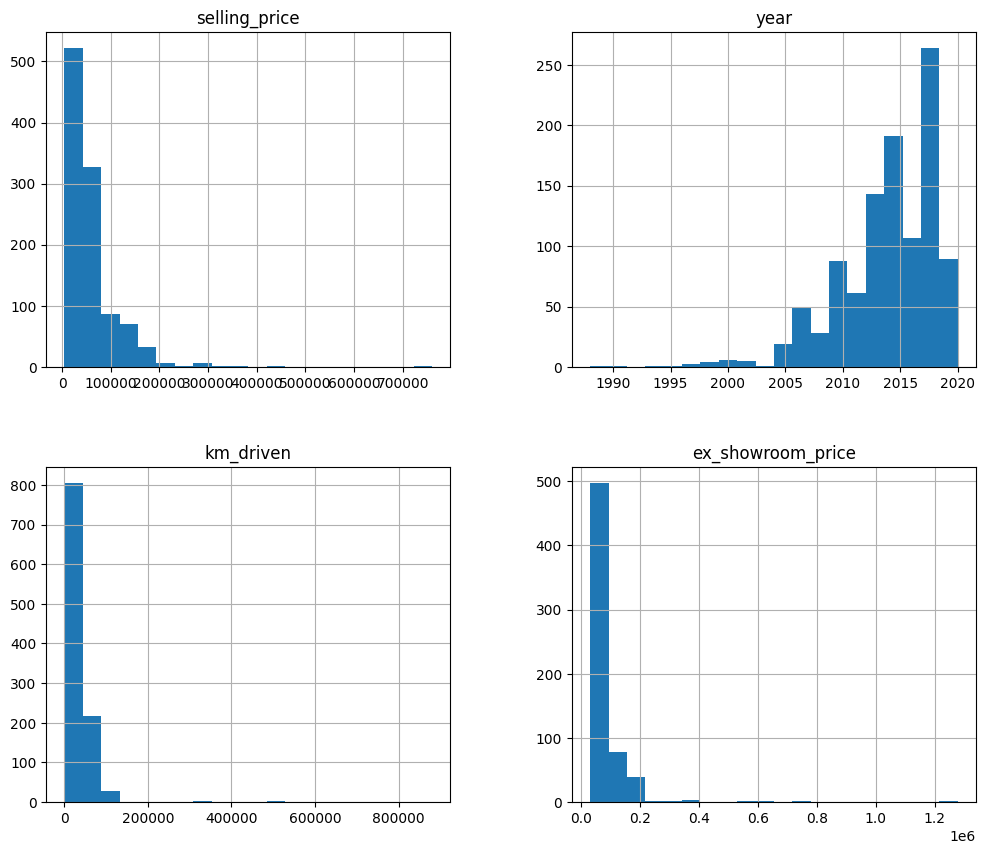

In [24]:
# Membuat grafik histogram untuk seluruh kolom numerik dalam dataframe secara sekaligus
# figsize=(12,10) mengatur ukuran total jendela grafik agar tidak saling bertumpuk
# bins=20 membagi data ke dalam 20 kelompok batang untuk melihat detail distribusi
df.hist(figsize=(12,10), bins=20)

# Menampilkan semua grafik histogram tersebut
plt.show()


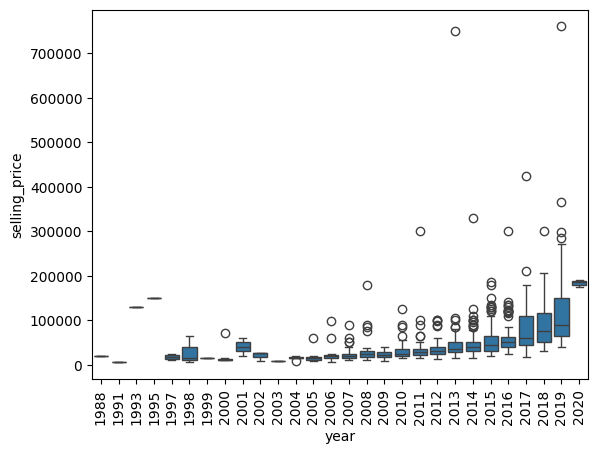

In [25]:
# Membuat grafik boxplot untuk membandingkan distribusi harga ('Price') di setiap kategori 'Location'
# Sumbu X menunjukkan nama lokasi, dan Sumbu Y menunjukkan rentang harga motornya
sns.boxplot(x='year', y='selling_price', data=df)
plt.xticks(rotation=90)

# Menampilkan grafik ke layar
plt.show()


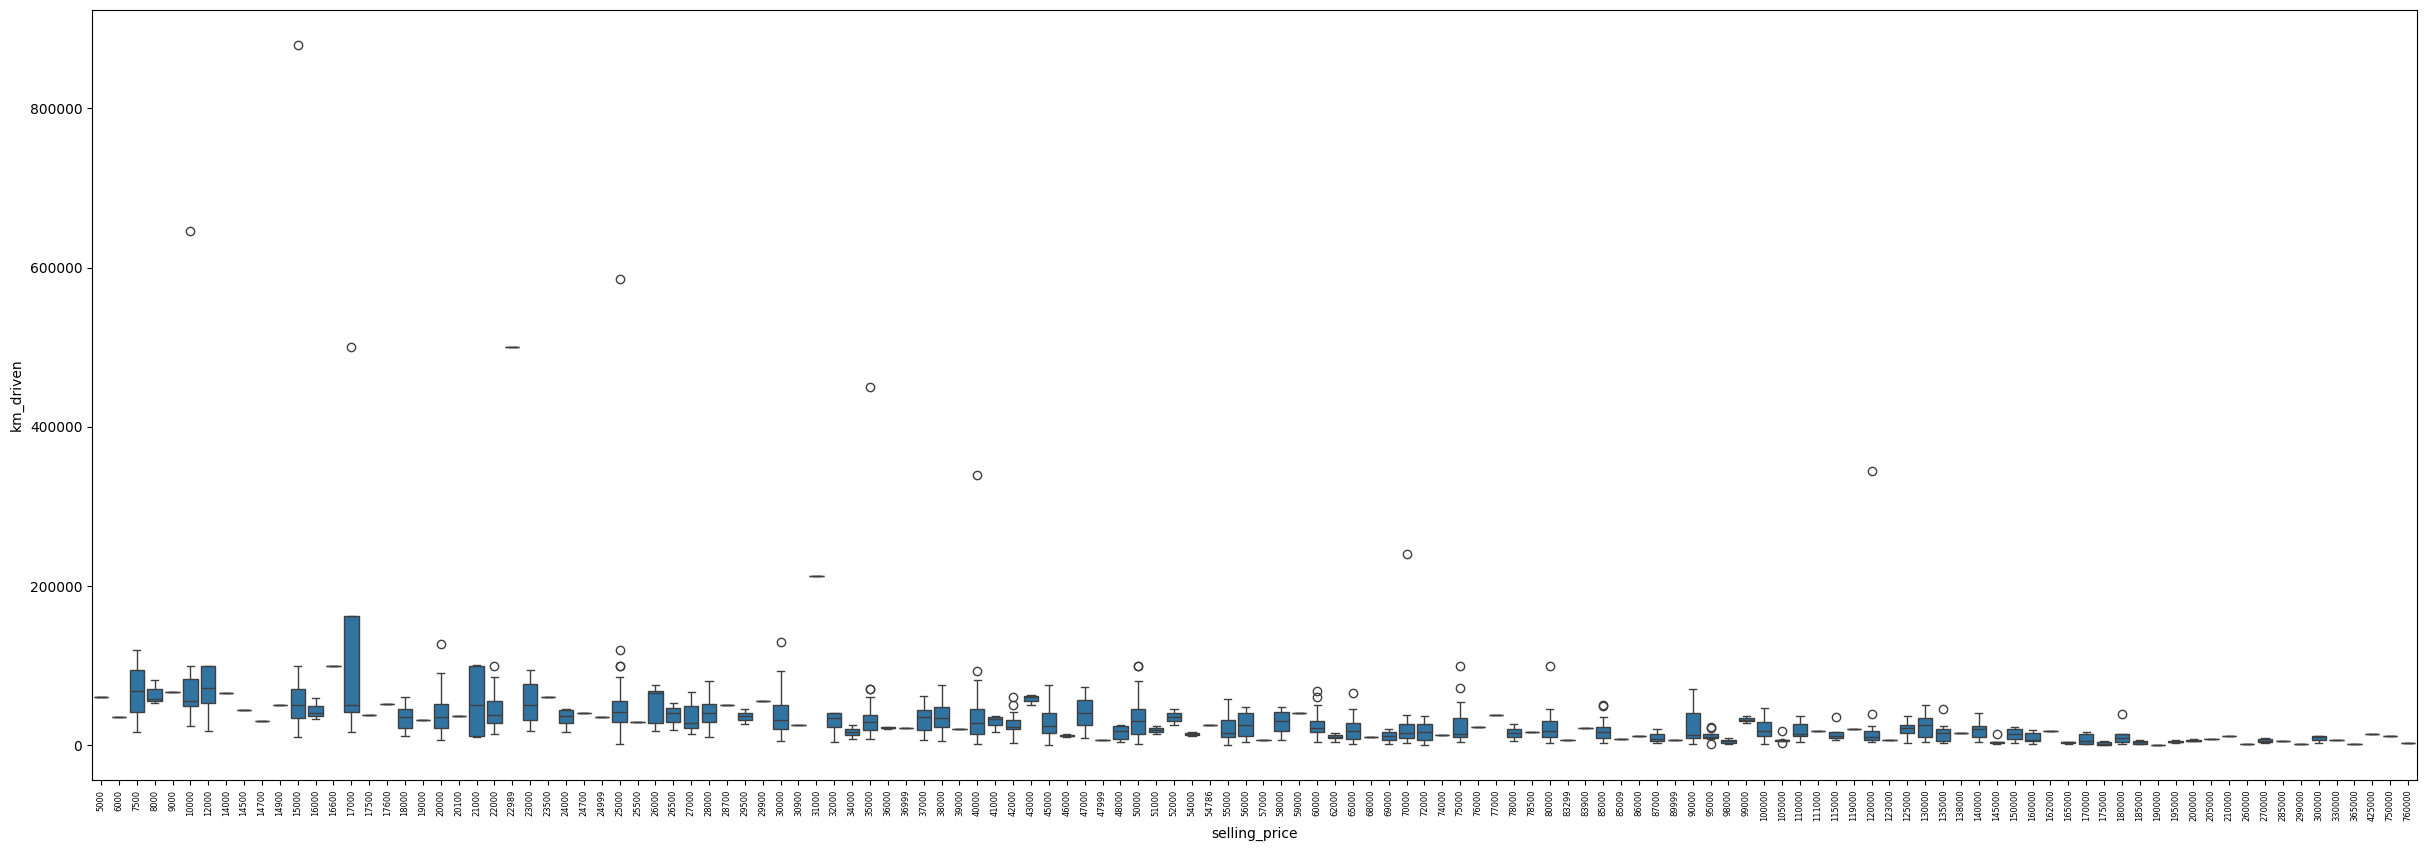

In [26]:
# Membuat grafik boxplot untuk melihat hubungan antara kategori 'Condition' (kondisi motor) dengan 'Price' (harga)
# Membantu memvisualisasikan bagaimana kondisi motor memengaruhi nilai jual dan sebaran harganya
plt.figure(figsize=(30, 10))

sns.boxplot(x='selling_price', y='km_driven', data=df)
plt.xticks(fontsize=6)
plt.xticks(rotation=90)

# Menampilkan grafik ke layar
plt.show()


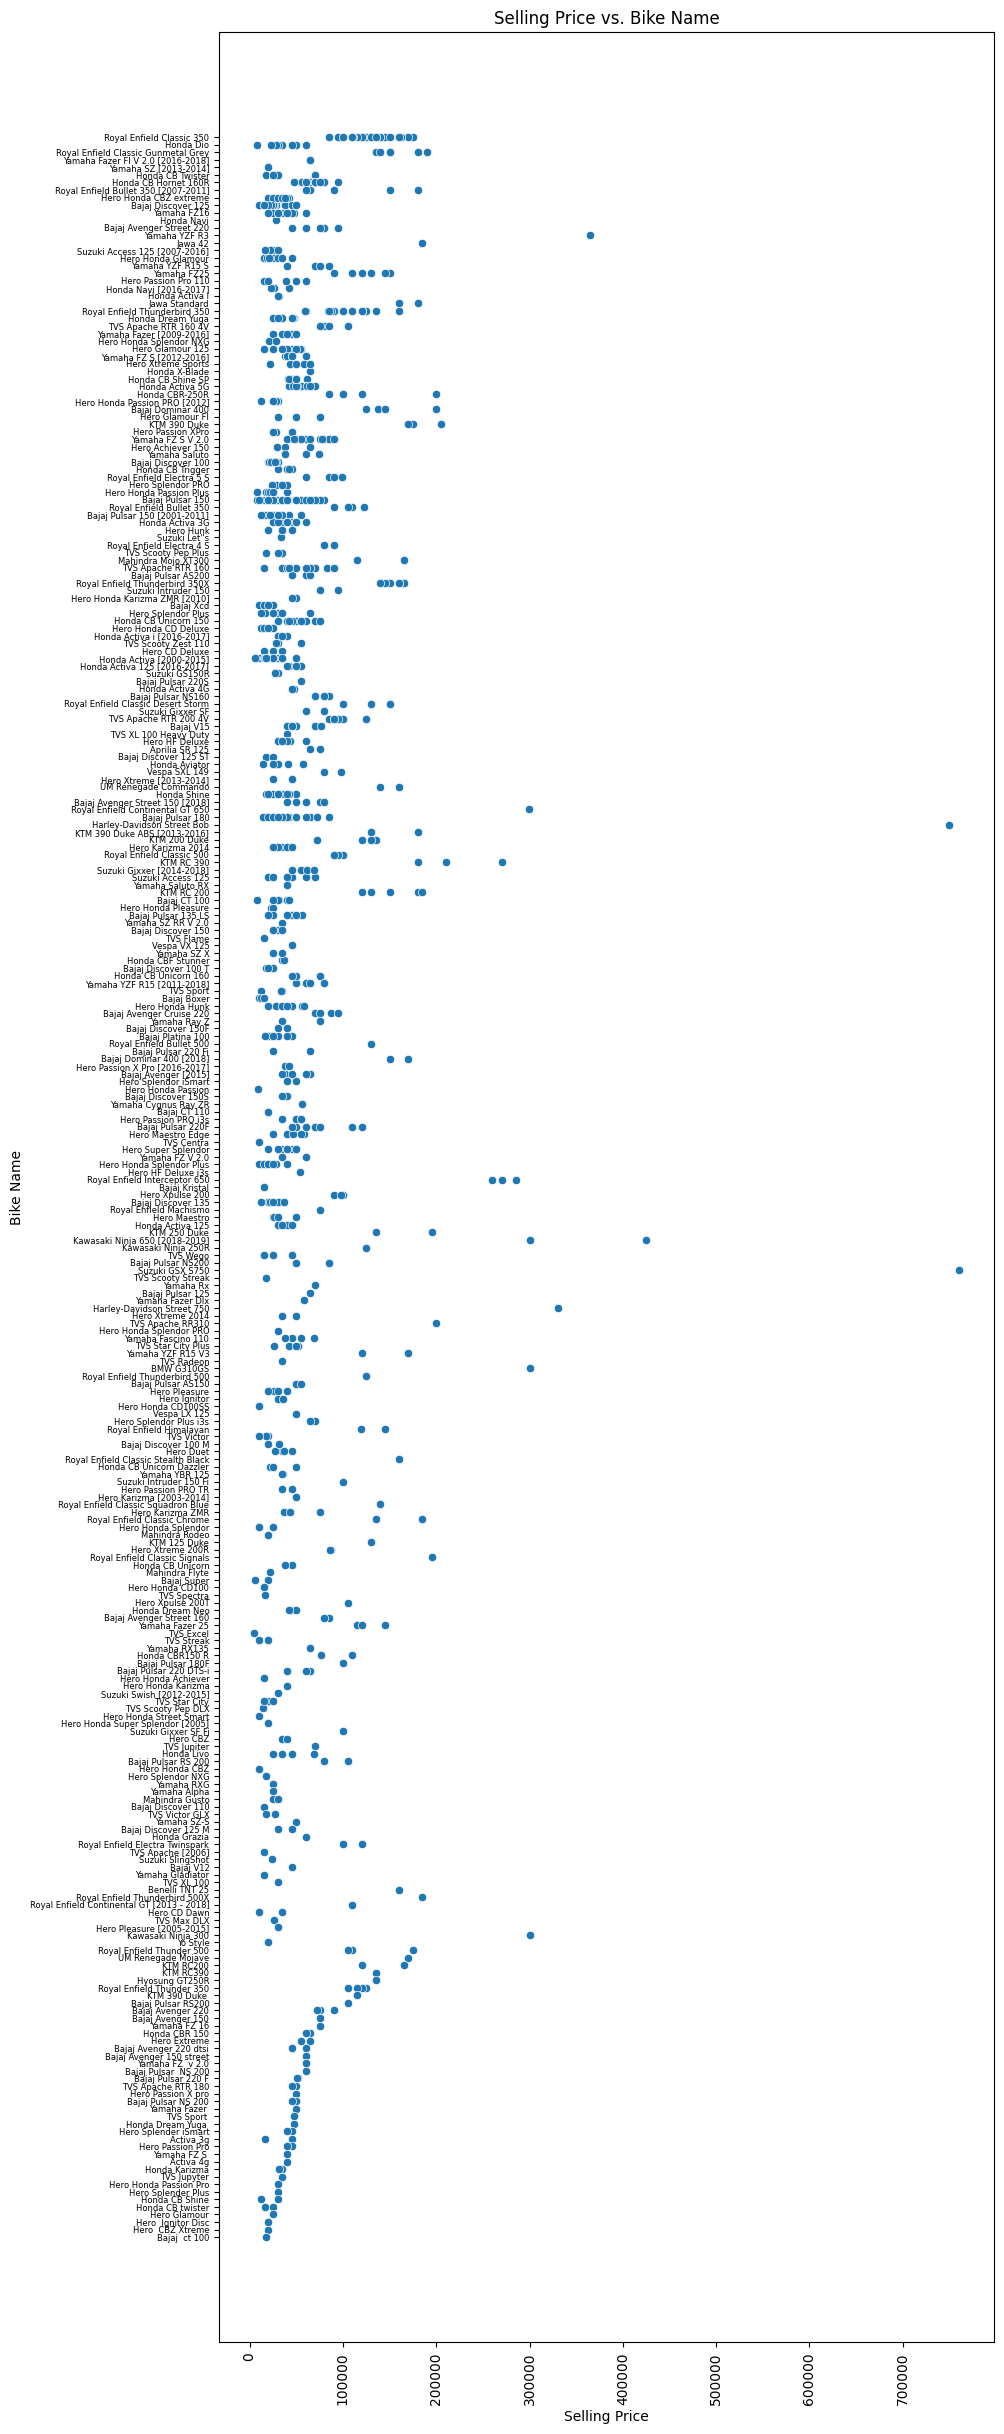

In [27]:
# Create the figure and axes with an increased height to accommodate many labels
plt.figure(figsize=(10, 30))

sns.scatterplot(x='selling_price', y='name', data=df)

# Reduce font size for y-axis labels for better readability with many categories
plt.yticks(fontsize=6)

# This was previously in the cell for x-axis rotation, keeping it for now
plt.xticks(rotation=90)

plt.title('Selling Price vs. Bike Name')
plt.xlabel('Selling Price')
plt.ylabel('Bike Name')

# The adjust_text function is not designed for axis tick labels or for directly adjusting their size.
# It is used for repositioning matplotlib.text.Text objects (annotations) to prevent them from overlapping.
# With 279 unique names, displaying all as individually readable axis labels on a single plot is challenging.

# Menampilkan grafik ke layar
plt.show()

# Data Preprocessing

## 1. Pembagian Data

In [28]:
# Mengimpor fungsi train_test_split dari library Scikit-learn untuk membagi data
from sklearn.model_selection import train_test_split

# Menentukan variabel independen (X) dengan mengambil semua kolom kecuali 'Price'
X = df.drop('selling_price', axis=1)

# Menentukan variabel target (y) yaitu kolom 'Price' yang ingin diprediksi
y = df['selling_price']

# Membagi data menjadi kumpulan data latih (train) dan data uji (test)
# test_size=0.2 berarti 20% data digunakan untuk pengujian, 80% untuk pelatihan
# random_state=42 digunakan agar hasil pembagian data tetap sama (konsisten) setiap kali kode dijalankan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
# Menampilkan dimensi (jumlah baris dan kolom) data fitur yang digunakan untuk melatih model (80% data)
print(X_train.shape)

# Menampilkan dimensi data fitur yang digunakan untuk menguji model (20% data)
print(X_test.shape)

# Menampilkan jumlah baris pada data target (harga) untuk pelatihan
print(y_train.shape)

# Menampilkan jumlah baris pada data target (harga) untuk pengujian
print(y_test.shape)


(848, 6)
(213, 6)
(848,)
(213,)


## 2. Encoding fitur kategorikal

In [30]:
# Mengubah data kategorikal biner pada kolom 'seller_type' di data latih (X_train)
# menjadi angka: 'Dealer' menjadi 0 dan 'Individual' menjadi 1 agar bisa diproses algoritma
X_train['seller_type'] = X_train['seller_type'].map({'Dealer': 0, 'Individual': 1})

# Melakukan hal yang sama pada data uji (X_test) untuk menjaga konsistensi format data
X_test['seller_type'] = X_test['seller_type'].map({'Dealer': 0, 'Individual': 1})

In [31]:
# Membuat kamus (dictionary) untuk menentukan urutan tingkatan kondisi motor dari yang terendah ke tertinggi
condition_mapping = {
    '4th owner': 0,      # Memberikan nilai 0 untuk kondisi paling rendah
    '3rd owner': 1,      # Memberikan nilai 1 untuk kondisi cukup
    '2nd owner': 2,      # Memberikan nilai 2 untuk kondisi baik
    '1st owner': 3  # Memberikan nilai 3 untuk kondisi sangat baik
}

# Menerapkan pemetaan (mapping) tersebut ke kolom 'Condition' pada data latih (X_train)
X_train['owner'] = X_train['owner'].map(condition_mapping)

# Menerapkan pemetaan yang sama ke kolom 'Condition' pada data uji (X_test) agar model tetap konsisten
X_test['owner'] = X_test['owner'].map(condition_mapping)


In [32]:
from sklearn.preprocessing import OneHotEncoder

# 3. Nominal (Location)
# Membuat objek encoder; drop='first' untuk menghindari jebakan multikolinieritas (dummy variable trap)
# handle_unknown='ignore' agar tidak error jika ada lokasi baru di data uji yang tidak ada di data latih
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Mempelajari kategori di data latih dan langsung mengubahnya menjadi matriks angka
X_train_loc = encoder.fit_transform(X_train[['name']])
# Mengubah data lokasi di data uji berdasarkan kategori yang sudah dipelajari dari data latih
X_test_loc = encoder.transform(X_test[['name']])

# Mendapatkan nama kolom baru hasil encoding (misalnya: Location_Suburb, Location_Urban, dll)
loc_columns = encoder.get_feature_names_out(['name'])

# Mengonversi hasil encoding kembali menjadi DataFrame dengan nama kolom dan index yang sesuai
X_train_loc = pd.DataFrame(X_train_loc, columns=loc_columns, index=X_train.index)
X_test_loc = pd.DataFrame(X_test_loc, columns=loc_columns, index=X_test.index)

# Menghapus kolom 'Location' asli yang masih berbentuk teks dari dataset utama
X_train = X_train.drop(columns=['name'])
X_test = X_test.drop(columns=['name'])

# Menggabungkan kembali dataframe utama dengan kolom-kolom baru hasil One-Hot Encoding
X_train = pd.concat([X_train, X_train_loc], axis=1)
X_test = pd.concat([X_test, X_test_loc], axis=1)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [33]:
# Menampilkan 5 baris pertama dari data fitur (X_train) setelah semua proses encoding selesai
# Digunakan untuk memastikan semua kolom sudah berubah menjadi angka dan kolom One-Hot Encoding sudah tergabung dengan benar
X_train.head()


,year,seller_type,owner,km_driven,ex_showroom_price,name_Activa 4g,name_Aprilia SR 125,name_Bajaj Avenger 150 street,name_Bajaj Avenger 220,name_Bajaj Avenger 220 dtsi,...,name_Yamaha SZ X,name_Yamaha SZ [2013-2014],name_Yamaha SZ-S,name_Yamaha Saluto,name_Yamaha YBR 125,name_Yamaha YZF R15 S,name_Yamaha YZF R15 V3,name_Yamaha YZF R15 [2011-2018],name_Yamaha YZF R3,name_Yo Style
72,2015,1,3,15856,92074.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
898,2015,1,2,46070,56147.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,2018,1,3,8000,84042.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,2018,1,3,22000,57557.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
784,2012,1,2,30000,49600.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# Menghitung jumlah kemunculan nilai 0 dan 1 pada kolom 'Garage' setelah proses encoding
# Digunakan untuk memastikan bahwa pemetaan 'No' -> 0 dan 'Yes' -> 1 telah berhasil diterapkan sepenuhnya
X_train['seller_type'].value_counts()


,count
seller_type,
1,843
0,5


In [35]:
# Menghitung jumlah kemunculan nilai numerik (0, 1, 2, 3) pada kolom 'Condition' setelah proses ordinal encoding
# Digunakan untuk memverifikasi bahwa tingkatan kondisi motor sudah berubah dari teks menjadi skala angka yang benar
X_train['year'].value_counts()


,count
year,
2017,104
2018,101
2016,95
2014,78
2015,71
2019,67
2012,60
2013,58
2010,52


In [36]:
# Mencari dan menampilkan 5 baris pertama hanya untuk kolom-kolom yang mengandung kata 'Location'
# Ini memudahkan Anda memeriksa apakah kolom baru hasil One-Hot Encoding sudah terbentuk dan berisi nilai 0 atau 1
X_train.filter(like='name').head()


,name_Activa 4g,name_Aprilia SR 125,name_Bajaj Avenger 150 street,name_Bajaj Avenger 220,name_Bajaj Avenger 220 dtsi,name_Bajaj Avenger Cruise 220,name_Bajaj Avenger Street 150 [2018],name_Bajaj Avenger Street 160,name_Bajaj Avenger Street 220,name_Bajaj Avenger [2015],...,name_Yamaha SZ X,name_Yamaha SZ [2013-2014],name_Yamaha SZ-S,name_Yamaha Saluto,name_Yamaha YBR 125,name_Yamaha YZF R15 S,name_Yamaha YZF R15 V3,name_Yamaha YZF R15 [2011-2018],name_Yamaha YZF R3,name_Yo Style
72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
784,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Normalisasi / Scaling (Menyamakan skala fitur supaya tidak ada yang “mendominasi” model)
Apakah semua model butuh scaling? Tidak ✔️ Butuh scaling:

Linear Regression
Ridge / Lasso
KNN
SVM
❌ Tidak wajib:

Decision Tree
Random **Forest**

In [37]:
# Menampilkan tipe data dari setiap kolom yang ada di dalam dataframe X_train
# Digunakan untuk memastikan seluruh fitur sudah bertipe angka (int64 atau float64)
# dan tidak ada lagi tipe 'object (teks) sebelum dimasukkan ke model machine learning
X_train.dtypes


,0
year,int64
seller_type,int64
owner,int64
km_driven,int64
ex_showroom_price,float64
...,...
name_Yamaha YZF R15 S,float64
name_Yamaha YZF R15 V3,float64
name_Yamaha YZF R15 [2011-2018],float64
name_Yamaha YZF R3,float64


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Menentukan daftar kolom numerik yang memiliki rentang nilai berbeda-beda untuk diseragamkan
num_cols = ['year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']

# Inisialisasi StandardScaler untuk mengubah data agar memiliki rata-rata (mean) 0 dan standar deviasi 1
scaler = StandardScaler()

# FIT & TRANSFORM hanya pada data latih (X_train)
# fit: menghitung mean dan standar deviasi dari data latih
# transform: mengubah nilai asli menggunakan hasil perhitungan tersebut
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# TRANSFORM pada data uji (X_test)
# Hanya menggunakan hasil perhitungan (mean/std) dari data latih agar tidak terjadi kebocoran data (data leakage)
X_test[num_cols] = scaler.transform(X_test[num_cols])


# Modeling

## Linear Regression

In [39]:
# Mengimpor kelas LinearRegression dari modul linear_model di Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Membuat objek/inisialisasi model Linear Regression
model = LinearRegression()

# --- FIX START: Impute missing values before training ---
# Identify columns with NaNs that need imputation
# Based on earlier analysis, 'ex_showroom_price' and 'owner' columns have NaNs.
# Impute missing values in 'ex_showroom_price' using the median
imputer_ex_showroom_price = SimpleImputer(strategy='median')
X_train['ex_showroom_price'] = imputer_ex_showroom_price.fit_transform(X_train[['ex_showroom_price']])
X_test['ex_showroom_price'] = imputer_ex_showroom_price.transform(X_test[['ex_showroom_price']])

# Impute missing values in 'owner' using the median
imputer_owner = SimpleImputer(strategy='median')
X_train['owner'] = imputer_owner.fit_transform(X_train[['owner']])
X_test['owner'] = imputer_owner.transform(X_test[['owner']])
# --- FIX END ---

# Melatih model (proses training) menggunakan data fitur (X_train) dan target (y_train)
# Di tahap ini, model belajar mencari hubungan garis lurus terbaik antara fitur motor dan harga
model.fit(X_train, y_train)


LinearRegression()

In [40]:
# Menggunakan model yang telah dilatih untuk memprediksi harga motor pada data uji (X_test)
# Hasil prediksi ini kemudian disimpan dalam variabel y_pred untuk dibandingkan dengan harga asli (y_test)
y_pred = model.predict(X_test)


In [41]:
# Mengimpor fungsi metrik evaluasi dari library Scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menghitung MAE: Rata-rata selisih mutlak antara harga asli dan prediksi (semakin kecil semakin baik)
mae = mean_absolute_error(y_test, y_pred)

# Menghitung MSE: Rata-rata selisih kuadrat (memberikan bobot lebih besar pada kesalahan yang besar)
mse = mean_squared_error(y_test, y_pred)

# Menghitung RMSE: Akar kuadrat dari MSE untuk mengembalikan satuan nilai ke satuan asli (Rupiah/Dollar)
rmse = mse ** 0.5

# Menghitung R2 Score: Menunjukkan seberapa baik model menjelaskan variasi data (mendekati 1 = sangat baik)
r2 = r2_score(y_test, y_pred)

# Menampilkan hasil evaluasi ke layar
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 15502.582192624277
RMSE: 31704.81822139879
R2: 0.6187805934808175


In [42]:
# Menghitung korelasi antar semua kolom numerik, lalu mengambil korelasi khusus terhadap kolom 'Price'
# sort_values(ascending=False) digunakan untuk mengurutkan hasil dari korelasi positif terkuat hingga korelasi negatif
df.corr(numeric_only=True)['selling_price'].sort_values(ascending=False)


,selling_price
selling_price,1.000000
ex_showroom_price,0.918583
year,0.402188
km_driven,-0.212937


In [43]:
# Menampilkan daftar nama kolom pada data latih (X_train)
print(X_train.columns)

# Menampilkan daftar nama kolom pada data uji (X_test)
# Digunakan untuk memastikan keduanya memiliki jumlah dan urutan fitur yang identik
print(X_test.columns)


Index(['year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price',
       'name_Activa 4g', 'name_Aprilia SR 125',
       'name_Bajaj Avenger 150 street', 'name_Bajaj Avenger 220',
       'name_Bajaj Avenger 220 dtsi',
       ...
       'name_Yamaha SZ X', 'name_Yamaha SZ [2013-2014]', 'name_Yamaha SZ-S',
       'name_Yamaha Saluto', 'name_Yamaha YBR 125', 'name_Yamaha YZF R15 S',
       'name_Yamaha YZF R15 V3', 'name_Yamaha YZF R15 [2011-2018]',
       'name_Yamaha YZF R3', 'name_Yo Style'],
      dtype='object', length=259)
Index(['year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price',
       'name_Activa 4g', 'name_Aprilia SR 125',
       'name_Bajaj Avenger 150 street', 'name_Bajaj Avenger 220',
       'name_Bajaj Avenger 220 dtsi',
       ...
       'name_Yamaha SZ X', 'name_Yamaha SZ [2013-2014]', 'name_Yamaha SZ-S',
       'name_Yamaha Saluto', 'name_Yamaha YBR 125', 'name_Yamaha YZF R15 S',
       'name_Yamaha YZF R15 V3', 'name_Yamaha YZF R15 [2011-2018]',
   

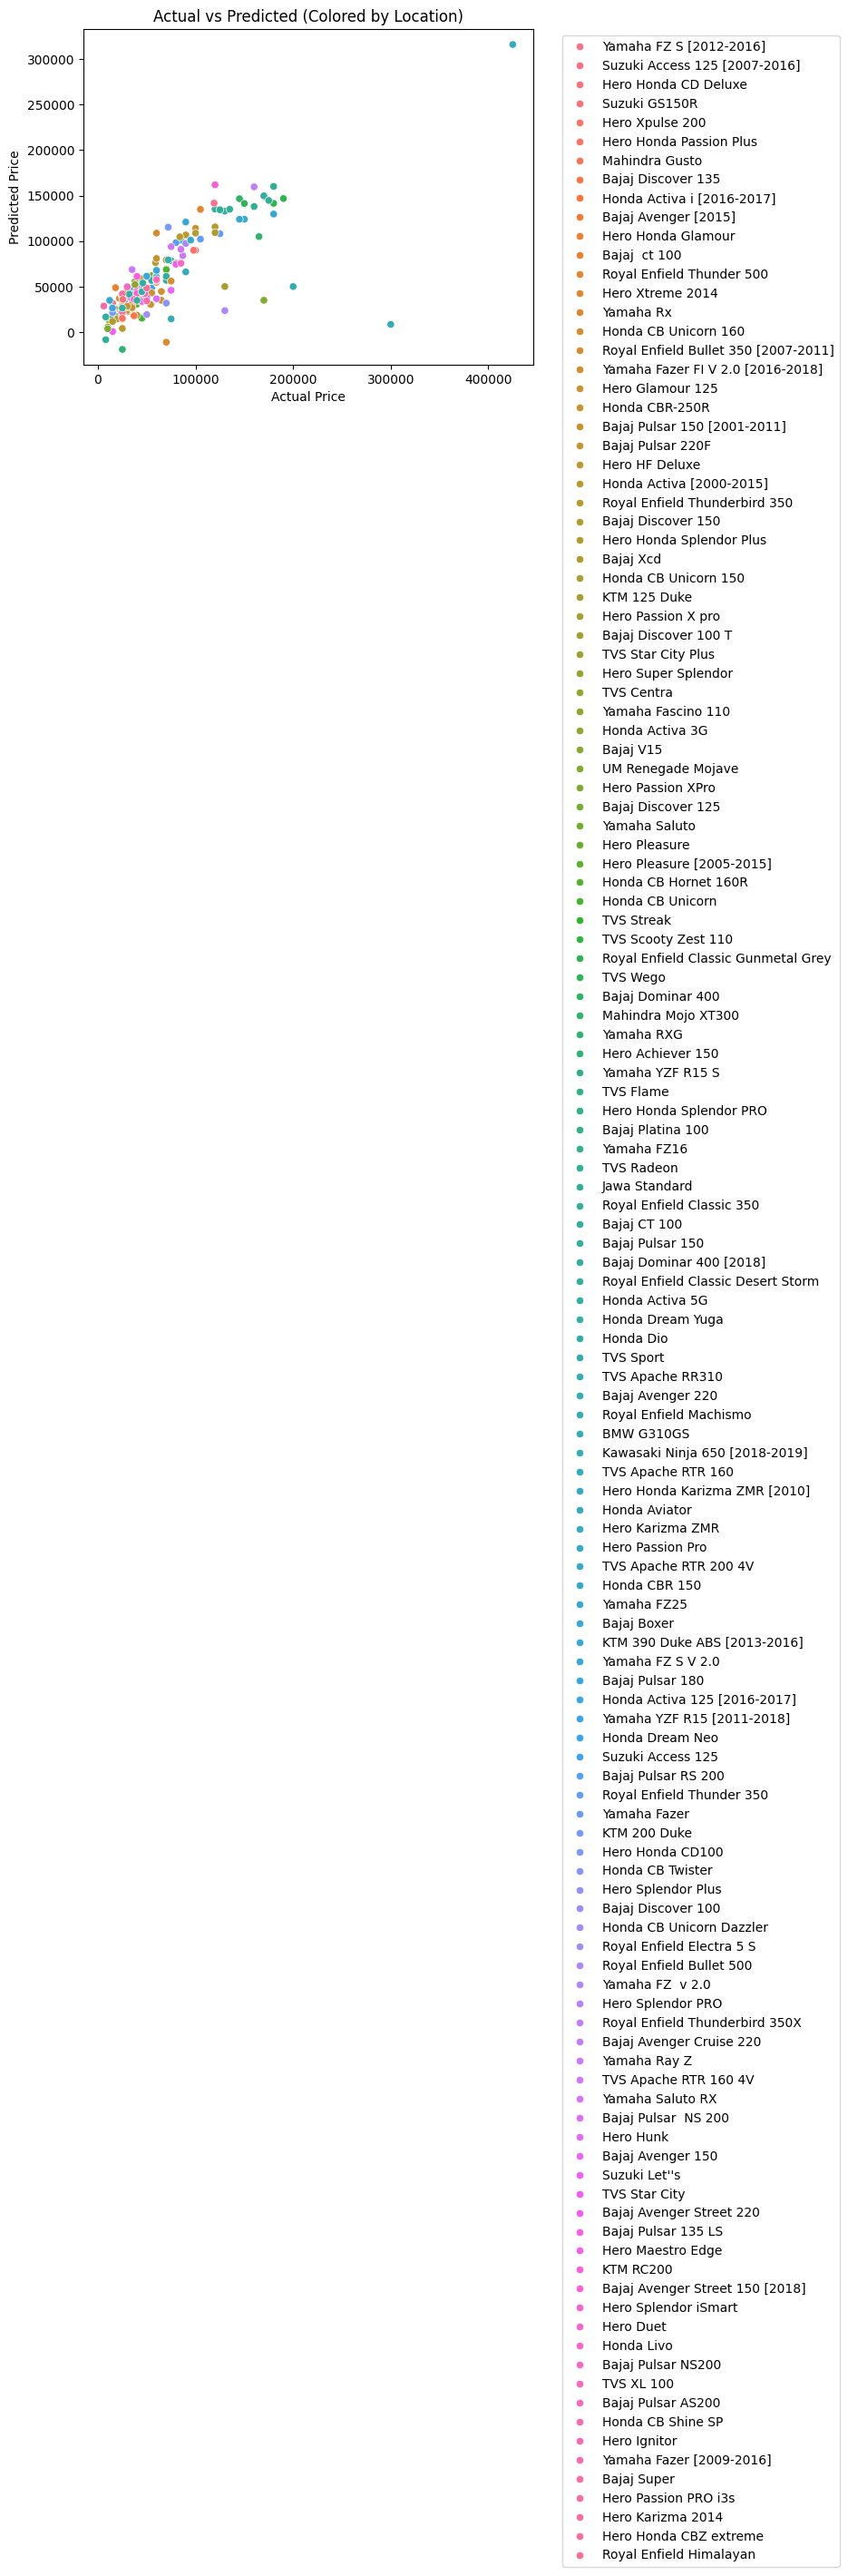

In [45]:
# Menambahkan warna berdasarkan kolom 'Location' dari data asli (df) agar lebih informatif
# Kita menggunakan index dari y_test untuk mengambil data lokasi yang sesuai
sns.scatterplot(x=y_test, y=y_pred, hue=df.loc[y_test.index, 'name'])

# Memberikan label pada sumbu X (Harga Asli)
plt.xlabel("Actual Price")

# Memberikan label pada sumbu Y (Harga Prediksi)
plt.ylabel("Predicted Price")

# Memberikan judul grafik
plt.title("Actual vs Predicted (Colored by Location)")

# Memindahkan legenda ke luar grafik agar tidak menutupi titik data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Menampilkan grafik
plt.show()


In [46]:
# Menggunakan model untuk memprediksi harga pada data yang digunakan saat latihan (X_train)
y_train_pred = model.predict(X_train)

# Menampilkan skor R2 untuk data latih (melihat seberapa baik model menghafal data latihan)
print("Train R2:", r2_score(y_train, y_train_pred))

# Menampilkan skor R2 untuk data uji (melihat seberapa baik model memprediksi data baru yang belum pernah dilihat)
print("Test R2:", r2_score(y_test, y_pred))


Train R2: 0.9641605739496351
Test R2: 0.6187805934808175


**Analisis Linear Regression**

Model Linear Regression menunjukkan nilai R² yang sangat kecil mendekati nol pada data training dan bernilai negatif pada data testing. Hal ini menunjukkan bahwa model belum mampu menangkap hubungan antara variabel independen dan harga motor dengan baik.

Rendahnya nilai R² mengindikasikan bahwa fitur yang digunakan belum cukup representatif atau hubungan antar variabel tidak bersifat linear.

## RandomForestRegressor

In [47]:
# Mengimpor algoritma RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Inisialisasi Model
# n_estimators=100 berarti kita menggunakan 100 pohon keputusan
# random_state agar hasil konsisten setiap kali dijalankan
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Melatih Model (Training)
# Model akan mempelajari pola dari data X_train dan target y_train
rf_model.fit(X_train, y_train)

# 3. Melakukan Prediksi
# Prediksi menggunakan data uji (X_test)
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluasi Hasil
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Performa Random Forest ---")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


--- Performa Random Forest ---
R2 Score: 0.859582448657964
MAE: 11898.587974960876


**Analisis Random Forest**

Model Random Forest juga menunjukkan performa yang kurang baik dengan nilai R² negatif sebesar -0.1206. Hal ini menandakan bahwa model tidak mampu melakukan prediksi secara akurat dan bahkan lebih buruk dibandingkan dengan pendekatan rata-rata.

Nilai MAE sebesar 255474.93 menunjukkan bahwa rata-rata kesalahan prediksi masih cukup besar, sehingga hasil prediksi belum dapat diandalkan.

# Kesimpulan

Perbandingan Kedua Model

Secara umum, kedua model belum memberikan performa yang optimal dalam memprediksi harga motor. Namun, jika dibandingkan:

* Linear Regression memiliki performa sedikit lebih baik dibandingkan Random Forest berdasarkan nilai R² yang lebih mendekati nol.
* Random Forest, meskipun secara teori lebih kompleks dan mampu menangani hubungan non-linear, pada penelitian ini belum menunjukkan keunggulannya.

**Faktor Penyebab**

Beberapa faktor yang mempengaruhi rendahnya performa kedua model antara lain:

* Data masih mengandung noise atau outlier
* Fitur yang digunakan kurang relevan
* Tidak dilakukan proses feature engineering
* Parameter model belum dioptimasi
* Dataset yang digunakan mungkin memiliki distribusi yang kompleks

Berdasarkan hasil evaluasi, dapat disimpulkan bahwa kedua model, baik Linear Regression maupun Random Forest, belum mampu memberikan hasil prediksi yang optimal. Linear Regression menunjukkan performa yang sedikit lebih baik, namun tetap belum cukup untuk digunakan sebagai model prediksi yang akurat.

Oleh karena itu, diperlukan perbaikan pada tahap preprocessing data, pemilihan fitur, serta optimasi model untuk meningkatkan kinerja prediksi.